# The Wildfire-Season trade — a quantitative teardown 🔬
### The ignition-day event study · a 20-seed random-calendar placebo · the [−1..+5] anatomy and its liability-window reading · a bootstrap/jackknife outlier autopsy · a utility-vs-insurer leg split · a basket-vs-SPY extra drop · a random-window seasonal placebo · a costed short-the-fire timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Seasonal%3F: Busted](https://img.shields.io/badge/Seasonal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — California fire season is a systematic, tradable risk event for the state's utilities and property insurers — has an unusually *real* mechanism (inverse-condemnation strict liability; PG&E's 2019 bankruptcy). The job here is to separate that genuine but *idiosyncratic and fundamental* liability risk from the *systematic, same-day, seasonal, tradable* pattern the folklore actually claims — and to grade each on the desk's inference bar.

> ⚠️ **Data note.** EIX/PCG (utilities) + ALL/TRV/MCY/CB (insurers) + SPY total-return closes (2003→2026), yfinance, cached; **14 hardcoded major California wildfires** 2003→2025, each flagged by utility-cause. Full coverage on every event (no survivorship gap on this axis) — but **PG&E's 2019 Chapter 11 and dilution are *inside* the `PCG` tape, not survivored out**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `62b4a2a1757b` EIX / `759d993391f0` PCG / `1ecb87f843e4` SPY, + 4 insurers).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wildfire_season import data, strategy as st

FIRES = data.fire_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SERIES = data.load_real()
    AR_SPY = st.abnormal_returns(st.daily_returns(SERIES["SPY"]))
    AR_BK = st.abnormal_returns(st.basket_returns(SERIES, data.BASKET_TICKERS))
    AR_UTIL = st.abnormal_returns(st.basket_returns(SERIES, data.UTIL_TICKERS))
    AR_INS = st.abnormal_returns(st.basket_returns(SERIES, data.INS_TICKERS))
    NAV_BK = st.basket_nav(SERIES, data.BASKET_TICKERS)
else:
    SERIES = AR_SPY = AR_BK = AR_UTIL = AR_INS = NAV_BK = None
print("real cache present:", HAVE_REAL, "| fires in table:", len(FIRES),
      "| utility-linked:", int(FIRES["utility_linked"].sum()))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 14, 'n_util_linked': 7, 'n_nonutil': 7, 'cal_lo': '2003-10-25', 'cal_hi': '2025-01-07', 'day0_mean_bps': -22.77, 'day0_t': -0.92, 'hit_down': 9, 'hit_n': 14, 'hit_pct': 64.3, 'wilson': (38.8, 83.7), 'placebo_mean_bps': -0.31, 'placebo_sd_bps': 36.04, 'placebo_p': 0.242, 'placebo_draws': 20000, 'event': {-1: (-57.05, 0.0, -2.17), 0: (-22.77, -22.77, -0.92), 1: (-74.35, -97.11, -1.38), 2: (-149.74, -246.86, -1.7), 3: (-66.23, -313.09, -1.18), 4: (-7.84, -320.92, -0.11), 5: (33.22, -287.71, 0.51)}, 'rev_mean_bps': -264.94, 'rev_t': -1.41, 'rev_ci': (-657.7, 41.4), 'rev_jk_below2': 14, 'rev_jk_n': 14, 'rev_jk_tmin': -1.61, 'rev_jk_tmax': -0.98, 'util_mean_bps': -704.11, 'util_t': -1.51, 'ins_mean_bps': -45.35, 'ins_t': -0.6, 'leg_diff_bps': -658.76, 'leg_diff_t': -1.54, 'ul_n': 7, 'ul_day0_bps': -22.27, 'ul_day0_t': -0.47, 'ul_rev_bps': -1596.35, 'ul_rev_t': -1.96, 'ul_jk_below2': 5, 'ul_jk_n': 7, 'ed_basket_bps': -264.94, 'ed_spy_bps': 24.86, 'ed_diff_bps': -289.8, 'ed_t': -1.71, 'ed_n': 14, 'seas_in_bps': 1.809, 'seas_out_bps': -1.777, 'seas_gap_bps': 3.586, 'seas_t': 1.019, 'seas_p': 0.297, 'timer': {5: (227.91, 30.9, 211.96, 1.19, 57), 10: (197.69, 141.15, 175.79, 1.16, 57), 21: (116.92, 11.37, 81.92, 0.45, 43)}, 'syn_null_mean': -0.09, 'syn_null_sd': 0.96, 'syn_null_fire': 1, 'syn_planted_t': -10.92, 'syn_planted_bps': -298.1, 'fp_eix': '62b4a2a1757b', 'fp_pcg': '759d993391f0', 'fp_all': '7898cdc31849', 'fp_trv': '3a070b43af0e', 'fp_mcy': 'c95d75857b2a', 'fp_cb': '36b3badbd526', 'fp_spy': '1ecb87f843e4'}


real cache present: True | fires in table: 14 | utility-linked: 7


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | ignition-day abnormal basket return **-22.77 bps**, one-sample **t = -0.92**, placebo **p = 0.242**; the [+1..+5] liability window is large but sub-bar (**-265 bps**, t = -1.41, bootstrap CI crosses 0, 14/14 leave-one-out below 2) |
| **Tradability** | `MIRAGE` | short-the-fire mean +212 bps but median only +31 bps (2-jackpot lottery), best net **t = +1.19**, win-rate 43% by 21d |
| **Fire-season seasonal?** | `BUSTED` | Jul→Dec gap **+3.59 bps/day** (wrong sign), Welch **t = +1.02**, random-window p = 0.30 |

> 💡 In plain words: the mechanism is real (utilities *can* be wrecked by a fire they caused), but it's a delayed, utility-only, concentrated *fundamental* event — not the systematic same-day/seasonal/tradable pattern the folklore sells. Every axis of the tradable claim comes back empty.

## 1 · The claim, steelmanned

Let $r_t$ be the equal-weight utility+insurer basket's daily return and $a_t = r_t - \bar{r}$ its abnormal return under a constant-mean market model (Brown & Warner 1985). For each fire $i$ with first-tradable-session date $\tau_i$:

- **H₁ (ignition dip).** $E[a_{\tau_i}] < 0$, large and systematic across events.
- **H₂ (post-fire crater).** $\sum_{k=1}^{5} a_{\tau_i+k} < 0$ — the drop, wherever it is, is real over the following week.
- **H₃ (insurers hit too).** The insurer leg falls, not just the utilities.
- **H₄ (fire-season seasonal).** The Jul→Dec window's mean abnormal return is materially below the rest of the year.
- **H₅ (capture).** A short-the-ignition overlay beats zero net of costs and borrow.

We find **H₁ not supported** (t = −0.92), **H₂ directionally real but sub-bar and outlier-fragile** (t = −1.41, bootstrap CI crosses 0, all leave-one-out below 2), **H₃ rejected** (insurer leg t = −0.60, ≈ flat), **H₄ rejected on sign** (fire window is mildly *positive*, Welch t = +1.02), **H₅ not supported** (a positive-mean, tiny-median lottery, never significant). The one place the effect nearly lives — the utility leg on utility-caused fires — reaches only t = −1.96 and is Camp/Eaton-driven.

## 2 · So what? — inference design

Fire events are **independent, non-overlapping calendar dates** (weeks to years apart), so the planned primary is a **one-sample t-test** across the 14 per-event abnormal returns — the unit of analysis is "one number per fire", not a daily panel, so no HAC correction is needed. Because a 14-event mean can be dominated by one or two megafires, the [+1..+5] window carries an **event bootstrap** 95% CI *and* a **leave-one-out jackknife** of the t-stat — the desk's outlier discipline. The hit rate carries a **Wilson interval**; the event placebo draws 14 random non-fire dates **20,000 times (20 seeds × 1,000)**; the [−1..+5] anatomy is a **7-offset multiple-comparison** (one spurious |t| ≥ 2 expected by chance); the seasonal carries a **random-6-month-window** null; the utility/insurer split and basket/SPY test are **paired** on the same dates so common market moves cancel.

## 3 · How we'd know — the protocol

- **Calendar.** 14 major California wildfires 2003-10-25 → 2025-01-07, hardcoded, 7 utility-linked / 7 not (cause flag from Cal Fire / CPUC / 8-K disclosures).
- **Tape.** EIX/PCG/ALL/TRV/MCY/CB + SPY total-return closes, 2003 → 2026-06-30 (as-of). Full coverage every event.
- **Headline.** Ignition-day (offset 0) one-sample t + Wilson hit rate + 20-seed placebo, on the combined basket.
- **Anatomy.** Event window [−1..+5], per-offset mean + t (multiple-comparison caveat); the [+1..+5] liability-window CAR with bootstrap CI + jackknife.
- **Splits.** Utility leg vs insurer leg ([+1..+5]); the utility-linked subset (n=7); paired basket − SPY extra drop.
- **Seasonal.** Jul→Dec vs rest-of-year daily-mean gap, Welch t + random-6-month-window placebo.
- **Execution (timer).** SHORT the basket at the ignition close (zero look-ahead — the ignition predates that session's close), exit `hold` sessions later; 2 × one-way cost × NAV + 300 bps/yr borrow; gross, net, *and median*.
- **Control.** Synthetic random-walk tape, planted mean-reverting dip; the null must not fire beyond nominal size across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo

One-sample t on the ignition-day (offset 0) abnormal basket return, Wilson hit rate, and the random-calendar null (a lighter 4-seed × 500 run in-notebook; the canonical 20,000-draw p is quoted from `results.md`).

ignition-day abnormal basket return -22.77 bps  one-sample t = -0.920  (n=14)
hit rate (down): 9/14 = 64.3%  Wilson [38.8%, 83.7%]


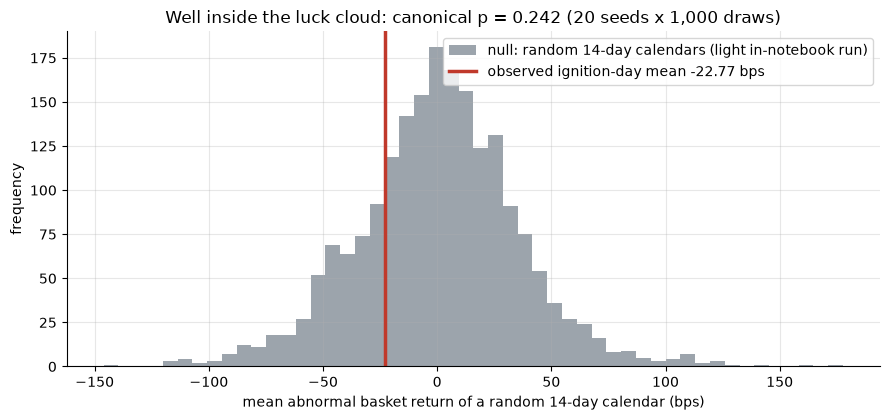

canonical placebo (results.md): mean -0.31 bps, sd 36.04 bps, p = 0.242


In [2]:
if HAVE_REAL:
    d0 = st.day0_stats(AR_BK, FIRES['date'], pre=1, post=5)
    wlo, whi = st.wilson_interval(d0['hit_down'], d0['n'])
    print(f"ignition-day abnormal basket return {d0['mean']*1e4:+.2f} bps  "
          f"one-sample t = {d0['t']:+.3f}  (n={d0['n']})")
    print(f"hit rate (down): {d0['hit_down']}/{d0['n']} = "
          f"{d0['hit_down']/d0['n']*100:.1f}%  Wilson [{wlo*100:.1f}%, {whi*100:.1f}%]")
    pl = np.concatenate([st.placebo_distribution(AR_BK, d0['n'], n_draws=500,
        seed=739 + s_, stat='day0') for s_ in range(4)])
    obs, draws = d0['mean'], pl
else:
    obs = R['day0_mean_bps'] / 1e4
    rng = np.random.default_rng(739)
    draws = rng.normal(R['placebo_mean_bps'] / 1e4, R['placebo_sd_bps'] / 1e4, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws * 1e4, bins=50, color=GREY, alpha=.85,
        label='null: random 14-day calendars (light in-notebook run)')
ax.axvline(obs * 1e4, c=RED, lw=2.5,
           label=f'observed ignition-day mean {obs*1e4:+.2f} bps')
ax.set_xlabel('mean abnormal basket return of a random 14-day calendar (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"Well inside the luck cloud: canonical p = {R['placebo_p']:.3f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean_bps']:+.2f} bps, "
      f"sd {R['placebo_sd_bps']:.2f} bps, p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed **-22.77 bps** sits well inside the null (-0.31 ± 36.04 bps); **p = 0.242**. With one-sample t = **-0.92** and a hit-rate Wilson interval [38.8%, 83.7%] straddling 50%, H₁ (a same-day ignition dip) does not clear the bar. On the day the fire breaks, the market doesn't yet know who's liable.

### 4b · Anatomy — the [−1..+5] window and the liability autopsy

Per-offset means + t (7-offset multiple comparison), then the [+1..+5] liability window with its bootstrap CI and leave-one-out jackknife — the outlier discipline that decides whether a big-looking mean is real.

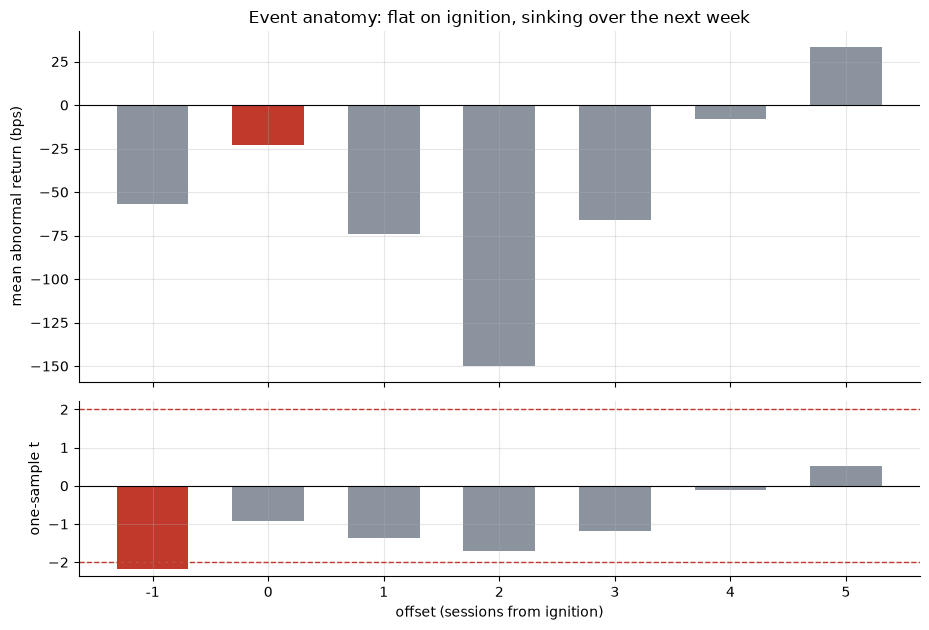

[+1..+5] liability CAR -264.9 bps (t=-1.41); bootstrap 95% CI [-658, +41] bps; |t|<2 in 14/14 leave-one-out drops


In [3]:
if HAVE_REAL:
    cp = st.car_path_stats(AR_BK, FIRES['date'], pre=1, post=5)
    ks = list(cp.index); ms = list(cp['mean_ar'] * 1e4); ts = list(cp['t'])
    rev = st.reversal_stats(AR_BK, FIRES['date'], pre=1, post=5)
    ci = st.block_bootstrap_ci(rev['per_event'])
    jk = st.jackknife_range(rev['per_event'])
    rev_m, rev_t = rev['mean'] * 1e4, rev['t']
    ci_lo, ci_hi = ci[0] * 1e4, ci[1] * 1e4
    jk_below, jk_n = jk['n_below2'], jk['n']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][2] for k in ks]
    rev_m, rev_t = R['rev_mean_bps'], R['rev_t']
    ci_lo, ci_hi = R['rev_ci']; jk_below, jk_n = R['rev_jk_below2'], R['rev_jk_n']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k == 0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (bps)')
a1.set_title('Event anatomy: flat on ignition, sinking over the next week')
a2.bar([str(k) for k in ks], ts,
       color=[RED if abs(t) >= 2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('one-sample t'); a2.set_xlabel('offset (sessions from ignition)')
plt.tight_layout(); plt.show()
print(f'[+1..+5] liability CAR {rev_m:+.1f} bps (t={rev_t:+.2f}); '
      f'bootstrap 95% CI [{ci_lo:+.0f}, {ci_hi:+.0f}] bps; '
      f'|t|<2 in {jk_below}/{jk_n} leave-one-out drops')

> 💡 In plain words: day 0 is **-22.77 bps** (t = -0.92); the drop *builds* over +1..+3 (the liability news landing), summing to **-265 bps** over [+1..+5]. But t = **-1.41**, the bootstrap CI **[-658, +41] bps crosses zero**, and **every** (14/14) leave-one-out drop keeps |t| under 2. The one bar that crosses the bar — offset **−1** (t = -2.17) — is on the *wrong side of the event* (before the fire is public), a textbook look-elsewhere false positive among 7 offsets.

### 4c · The splits — utilities vs insurers, and the utility-linked subset

Same dates: which leg carries the drop, and what happens when we restrict to the 7 fires a utility's equipment (likely) caused.

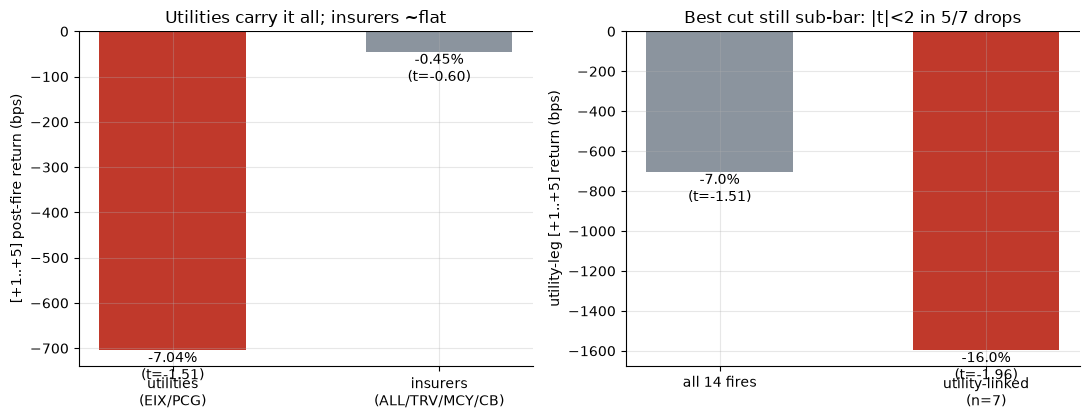

utility -7.04% (t=-1.51) vs insurer -0.45% (t=-0.60)
utility-linked subset: day0 -22.3 bps (t=-0.47); [+1..+5] -16.0% (t=-1.96); |t|<2 in 5/7 drops


In [4]:
if HAVE_REAL:
    lc = st.leg_compare(AR_UTIL, AR_INS, FIRES['date'], pre=1, post=5, window='post')
    ul = FIRES.loc[FIRES['utility_linked'], 'date']
    rev_ul = st.reversal_stats(AR_UTIL, ul, pre=1, post=5)
    d0_ul = st.day0_stats(AR_UTIL, ul, pre=1, post=5)
    jk_ul = st.jackknife_range(rev_ul['per_event'])
    util_b, ins_b = lc['util_mean'] * 1e4, lc['ins_mean'] * 1e4
    ut_ut, in_t = lc['util_t'], lc['ins_t']
    ul_m, ul_t = rev_ul['mean'] * 1e4, rev_ul['t']
    ul_d0, ul_d0t = d0_ul['mean'] * 1e4, d0_ul['t']
    ul_below, ul_n = jk_ul['n_below2'], jk_ul['n']
else:
    util_b, ins_b = R['util_mean_bps'], R['ins_mean_bps']
    ut_ut, in_t = R['util_t'], R['ins_t']
    ul_m, ul_t = R['ul_rev_bps'], R['ul_rev_t']
    ul_d0, ul_d0t = R['ul_day0_bps'], R['ul_day0_t']
    ul_below, ul_n = R['ul_jk_below2'], R['ul_jk_n']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['utilities\n(EIX/PCG)', 'insurers\n(ALL/TRV/MCY/CB)'], [util_b, ins_b],
       color=[RED, GREY], width=.55)
for i, (v, t2) in enumerate([(util_b, ut_ut), (ins_b, in_t)]):
    a1.annotate(f'{v/100:+.2f}%\n(t={t2:+.2f})', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('[+1..+5] post-fire return (bps)')
a1.set_title('Utilities carry it all; insurers ~flat')
a2.bar(['all 14 fires', 'utility-linked\n(n=7)'], [R['util_mean_bps'], ul_m],
       color=[GREY, RED], width=.55)
for i, (v, t2) in enumerate([(R['util_mean_bps'], R['util_t']), (ul_m, ul_t)]):
    a2.annotate(f'{v/100:+.1f}%\n(t={t2:+.2f})', (i, v), ha='center', va='top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('utility-leg [+1..+5] return (bps)')
a2.set_title(f'Best cut still sub-bar: |t|<2 in {ul_below}/{ul_n} drops')
plt.tight_layout(); plt.show()
print(f'utility {util_b/100:+.2f}% (t={ut_ut:+.2f}) vs insurer {ins_b/100:+.2f}% (t={in_t:+.2f})')
print(f'utility-linked subset: day0 {ul_d0:+.1f} bps (t={ul_d0t:+.2f}); '
      f'[+1..+5] {ul_m/100:+.1f}% (t={ul_t:+.2f}); |t|<2 in {ul_below}/{ul_n} drops')

> 💡 In plain words: the utility leg gives up **-7.04%** post-fire (t = -1.51); the insurer leg **-0.45%** (t = -0.60) — H₃ rejected, insurers are diversified/reinsured. Restricting the utility leg to the 7 utility-caused fires drives the [+1..+5] drop to **-16.0%** — but only **t = -1.96** (one hair short of 2) and **5/7 leave-one-out drops fall below 2**: take out Camp *or* Eaton and it evaporates. And the ignition day *within* this subset is still flat (-22.3 bps, t = -0.47) — confirming a delayed liability repricing, not a same-day event.

### 4d · The seasonal — is fire season a bad time to own the basket?

Jul→Dec fire-window mean daily abnormal return vs the rest of the year, with a random-6-month-window null.

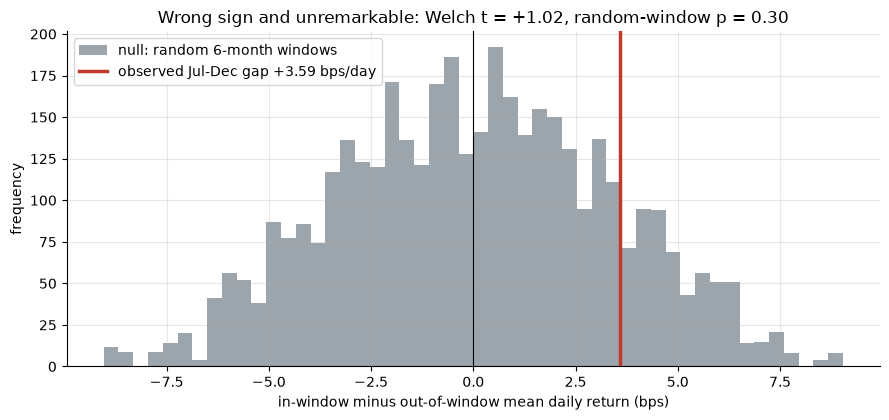

fire window +1.809 bps/day vs rest -1.777 bps/day -> gap +3.586 bps/day (Welch t=+1.02, random-window p=0.297)


In [5]:
if HAVE_REAL:
    seas = st.seasonal_test(AR_BK, fire_months=data.FIRE_MONTHS)
    sp = st.seasonal_placebo(AR_BK, k_months=len(data.FIRE_MONTHS), n_draws=4000, seed=739)
    gap, tt = seas['diff'] * 1e4, seas['t']
    p_seas = float((np.abs(sp) >= abs(seas['diff'])).mean())
    inb, outb = seas['in_mean'] * 1e4, seas['out_mean'] * 1e4
else:
    gap, tt, p_seas = R['seas_gap_bps'], R['seas_t'], R['seas_p']
    inb, outb = R['seas_in_bps'], R['seas_out_bps']
    rng = np.random.default_rng(739)
    sp = rng.normal(0, abs(R['seas_gap_bps'] / 1e4) / 1.04, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(sp * 1e4, bins=50, color=GREY, alpha=.85,
        label='null: random 6-month windows')
ax.axvline(gap, c=RED, lw=2.5, label=f'observed Jul-Dec gap {gap:+.2f} bps/day')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('in-window minus out-of-window mean daily return (bps)')
ax.set_ylabel('frequency')
ax.set_title(f'Wrong sign and unremarkable: Welch t = {tt:+.2f}, random-window p = {p_seas:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'fire window {inb:+.3f} bps/day vs rest {outb:+.3f} bps/day -> '
      f'gap {gap:+.3f} bps/day (Welch t={tt:+.2f}, random-window p={p_seas:.3f})')

> 💡 In plain words: H₄ predicts a materially **negative** fire-window gap. We measure **+3.59 bps/day** — *positive*, wrong sign, Welch t = **+1.02**, and a random 6-month calendar slice produces a gap this large about **30%** of the time. Utilities are defensive dividend names that tend to do *better* in autumn risk-off; the calendar does not price fire risk in advance. Busted.

### 4e · The timer — short-the-fire cost & borrow sweep

*Clinical test of public market data.* SHORT the basket at the ignition close (zero look-ahead), hold `h` sessions; 5 bps one-way charged twice + 300 bps/yr borrow prorated over the hold. The **median** is reported next to the mean because that gap is the whole story.

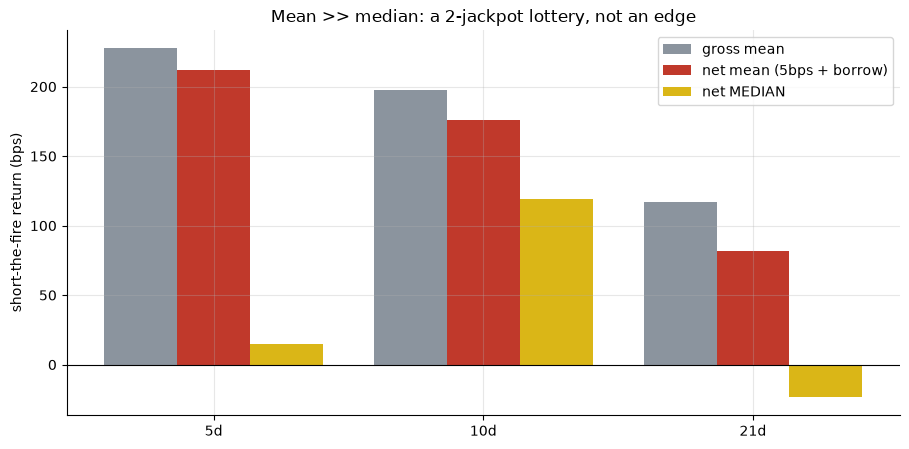

gross mean (bps): {5: 227.9, 10: 197.7, 21: 116.9}
net mean (bps): {5: 212.0, 10: 175.8, 21: 81.9}
net median (bps): {5: 14.9, 10: 119.2, 21: -23.6}
net t / win% : {5: '+1.19/57%', 10: '+1.16/57%', 21: '+0.45/43%'}


In [6]:
if HAVE_REAL:
    holds = [5, 10, 21]; gross = []; net = []; med = []; ts = []; wins = []
    for h in holds:
        lg_g = st.fire_timer(NAV_BK, FIRES['date'], hold=h, cost_bps=0.0,
                             borrow_bps_annual=0.0)
        g = st.summarize_timer(lg_g, col='ret_gross')
        lg_n = st.fire_timer(NAV_BK, FIRES['date'], hold=h, cost_bps=5.0,
                             borrow_bps_annual=300.0)
        n_ = st.summarize_timer(lg_n, col='ret_net')
        gross.append(g['mean_bps']); net.append(n_['mean_bps'])
        med.append(n_['median_bps']); ts.append(n_['t']); wins.append(n_['win_rate']*100)
else:
    holds = sorted(R['timer'])
    gross = [R['timer'][h][0] for h in holds]
    net = [R['timer'][h][2] for h in holds]
    med = [R['timer'][h][1] for h in holds]
    ts = [R['timer'][h][3] for h in holds]
    wins = [R['timer'][h][4] for h in holds]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(holds)); w = 0.27
ax.bar(x - w, gross, width=w, color=GREY, label='gross mean')
ax.bar(x, net, width=w, color=RED, label='net mean (5bps + borrow)')
ax.bar(x + w, med, width=w, color=AMBER, label='net MEDIAN')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('short-the-fire return (bps)')
ax.set_title('Mean >> median: a 2-jackpot lottery, not an edge')
ax.legend(); plt.tight_layout(); plt.show()
print('gross mean (bps):', dict(zip(holds, [round(v,1) for v in gross])))
print('net mean (bps):', dict(zip(holds, [round(v,1) for v in net])))
print('net median (bps):', dict(zip(holds, [round(v,1) for v in med])))
print('net t / win% :', dict(zip(holds, [f'{t:+.2f}/{w:.0f}%' for t, w in zip(ts, wins)])))

> 💡 In plain words: at the 5-day hold the short nets a mean **+212 bps** but a **median of only +31 bps** (net t = +1.19) — the mean is two jackpots (Camp, Eaton) inside 14 bets. H₅ is not supported: never significant, and by 21 days the win rate is **43%** (you lose more often than you win) while you bleed borrow shorting defensive dividend stocks. A negative-carry bet on a rare, un-timeable liability crater.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic random-walk tape, 14 scheduled pseudo-fire dates, TUNABLE planted day-0 dip reverting over 5 sessions. The null (dip=0) is checked over **20 seeds** — never a single stream.

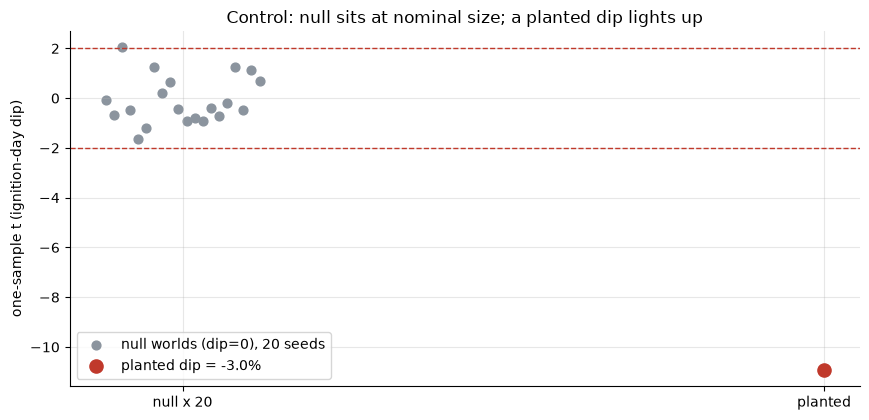

null: mean t = -0.09 (sd 0.96), |t|>=2 in 1/20 seeds  |  planted t = -10.92


In [7]:
null_ts = []
for s_ in range(20):
    close, ev = data.synthetic_world(dip=0.0, seed=739 + s_)
    null_ts.append(st.synthetic_detect(close, ev, stat='day0')['t'])
null_ts = np.asarray(null_ts)
close, ev = data.synthetic_world(dip=-0.03, seed=739)
planted_t = st.synthetic_detect(close, ev, stat='day0')['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (dip=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted dip = -3.0%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (ignition-day dip)')
ax.set_title('Control: null sits at nominal size; a planted dip lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.09 (sd 0.96) and crosses the bar in **1/20** seeds — the nominal 5% false-positive rate, not a broken detector; a planted 3% dip reads t = -10.92. The machinery is unbiased, so the real-tape ignition-day t ≈ −0.92 is a genuine null, not a detector asleep. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — ignition-day abnormal basket return **-22.77 bps**, one-sample t = **-0.92**, placebo p = **0.242**. The [+1..+5] liability window is large (**-265 bps**) but sub-bar and outlier-fragile (t = -1.41, bootstrap CI [-658, +41] crosses 0, 14/14 leave-one-out below 2); insurers ≈ flat (t = -0.60); the best cut (utility leg, utility-caused fires) reaches only t = -1.96, Camp/Eaton-driven (5/7 drops below 2). The one significant offset (−1, t = -2.17) is a wrong-side look-elsewhere artifact.
- **Tradability `MIRAGE`** — short-the-fire mean +212 bps but median +31 bps, best net t = +1.19, win-rate 43% by 21d. A 2-jackpot lottery with negative carry, not a costable edge.
- **"A fire-season seasonal?" `BUSTED`** — Jul→Dec gap **+3.59 bps/day** (wrong sign), Welch t = +1.02, random-window p = 0.30.

The mechanism is real — inverse-condemnation liability *can* and did wreck a utility (PG&E) — but it manifests as a **delayed, utility-only, concentrated fundamental repricing**, not the systematic same-day, basket-wide, seasonal, tradable pattern the folklore sells.

## 6 · Going further

- **Power is the honest limitation, in both directions.** n=14 (7 utility-linked) is small, and the [+1..+5] utility-caused effect is real enough that a *larger* sample might certify it — but a signal that lives or dies on Camp and Eaton is, by construction, not something you can *rely on ex-ante*.
- **A cause-conditional design** — event-time keyed to the *public attribution* of a utility as the ignition suspect (an 8-K, a CPUC filing) rather than the ignition itself — is the natural next test, but that news is typically already in the price; single-name utility options around known investigation catalysts are the more honest capacity question.
- **Dedup map:** [707-plane-crash-effect](../../707-plane-crash-effect/) (the mirror image — a *sentiment* claim on a broad index, also None/Mirage) and [313-geopolitical-shock](../../313-geopolitical-shock/) (hardcoded shock calendar, same random-calendar placebo design).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*